# Análisis de Cartera con la Clase Portfolio

Este notebook demuestra cómo utilizar la clase `Portfolio` del módulo `functions_portfolio` para analizar una cartera de fondos de inversión.

In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2


In [2]:
import pandas as pd
import sys
import os

# Añadir el directorio src al path para poder importar los módulos
sys.path.append(os.path.abspath('.'))

from functions_portfolio import Portfolio
from functions_fund import Fund

# Configurar pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)

## 1. Creación de una Cartera de Ejemplo

Definimos una cartera de ejemplo en un DataFrame de pandas. Es importante proporcionar `Nombre`, `ISIN` e `Inversion`. La `Fecha` de compra es opcional, pero recomendada para un cálculo de rentabilidad más preciso.

In [3]:
# Crear un DataFrame de ejemplo para la cartera
# Usaremos ISINs reales para obtener datos
portfolio_data = {
    'Nombre': [
        'Fidelity MSCI World',
        'Vanguard Global Stock Index',
        'MyInvestor Roboadvisor Agresivo',
        'CaixaBank RF Flexible'
    ],
    'ISIN': [
        'IE00BYX5MX67', # Fidelity MSCI World P-ACC-EUR
        'IE00B03HD191', # Vanguard Global Stock Index Fund EUR Acc
        'ES0133337008', # MyInvestor Cartera Agresiva PP
        'ES0133411001'  # CaixaBank Renta Fija Flexible
    ],
    'Inversion': [1500, 2500, 3000, 2000],
    'Fecha': ['2023-01-15', '2022-06-20', '2023-03-10', '2022-11-05']
}

portfolio_df = pd.DataFrame(portfolio_data)

print("Cartera de ejemplo:")
display(portfolio_df)

Cartera de ejemplo:


,Nombre,ISIN,Inversion,Fecha
0,Fidelity MSCI World,IE00BYX5MX67,1500,2023-01-15
1,Vanguard Global Stock Index,IE00B03HD191,2500,2022-06-20
2,MyInvestor Roboadvisor Agresivo,ES0133337008,3000,2023-03-10
3,CaixaBank RF Flexible,ES0133411001,2000,2022-11-05


## 2. Inicialización y Análisis de la Cartera

Creamos una instancia de la clase `Portfolio`. Al inicializarse, automáticamente recopila y procesa toda la información de los fondos (datos de Morningstar, Finect, Yahoo Finance, etc.).

Luego, llamamos a `analyze_portfolio()` para obtener un análisis completo.

In [4]:
portfolio_df

,Nombre,ISIN,Inversion,Fecha
0,Fidelity MSCI World,IE00BYX5MX67,1500,2023-01-15
1,Vanguard Global Stock Index,IE00B03HD191,2500,2022-06-20
2,MyInvestor Roboadvisor Agresivo,ES0133337008,3000,2023-03-10
3,CaixaBank RF Flexible,ES0133411001,2000,2022-11-05


In [5]:
portfolio = Portfolio(portfolio_df=portfolio_df.copy(), use_cache=True)


Cache manager initialized with base path: c:\Users\jaguirrepeman\OneDrive - Deloitte (O365D)\Documents\DS\Finance\data\cache
  ✓ Usando datos en caché para IE00BYX5MX67
  ✓ Usando datos en caché para IE00BYX5MX67
Cache manager initialized with base path: c:\Users\jaguirrepeman\OneDrive - Deloitte (O365D)\Documents\DS\Finance\data\cache
  ✓ Usando datos en caché para IE00B03HD191
  ✓ Usando datos en caché para IE00B03HD191
Cache manager initialized with base path: c:\Users\jaguirrepeman\OneDrive - Deloitte (O365D)\Documents\DS\Finance\data\cache
  ✓ Usando datos en caché para ES0133337008
  ✓ Usando datos en caché para ES0133337008
Cache manager initialized with base path: c:\Users\jaguirrepeman\OneDrive - Deloitte (O365D)\Documents\DS\Finance\data\cache
  ✓ Usando datos en caché para ES0133411001
  ✓ Usando datos en caché para ES0133411001


In [6]:
# Realizar un análisis completo de la cartera
analysis_results = portfolio.analyze_portfolio_returns()

In [7]:
portfolio_df_ = portfolio.portfolio_df.copy()


--- Analizando composición de cartera con 4 fondos ---

📊 RESUMEN GENERAL DE LA CARTERA
Inversión total: 9,000.00€
Valor actual: 12,027.15€
Rentabilidad total: 33.64%

📈 DISTRIBUCIÓN POR TIPO DE ACTIVO
Distribución por tipo de activo:
  • Otros: 100.00%
✓ Gráfico de distribución por tipo de activo generado

📊 ANÁLISIS DE RENDIMIENTO

⚠️ ANÁLISIS DE RIESGO
Volatilidad media ponderada: 12.11%

Distribución por nivel de volatilidad:
  • Muy baja (< 5%): 33.3%
  • Media (10-15%): 22.2%
  • Alta (15-20%): 27.8%
  • Muy alta (> 20%): 16.7%

Máximo drawdown medio ponderado: -26.96%

Fondos con mayor drawdown:
Vanguard Global Stock Index: -33.76% (27.8% de la cartera)
Fidelity MSCI World: -33.62% (16.7% de la cartera)
CaixaBank RF Flexible: -29.71% (22.2% de la cartera)

💰 ANÁLISIS DE COSTES

🌎 DIVERSIFICACIÓN GEOGRÁFICA
⚠️ No se encontraron datos de distribución geográfica

⭐ ANÁLISIS DE CALIDAD (RATINGS)
Rating Morningstar medio ponderado: 3.22 estrellas

⚠️ FONDOS POTENCIALMENTE INEFICIENT

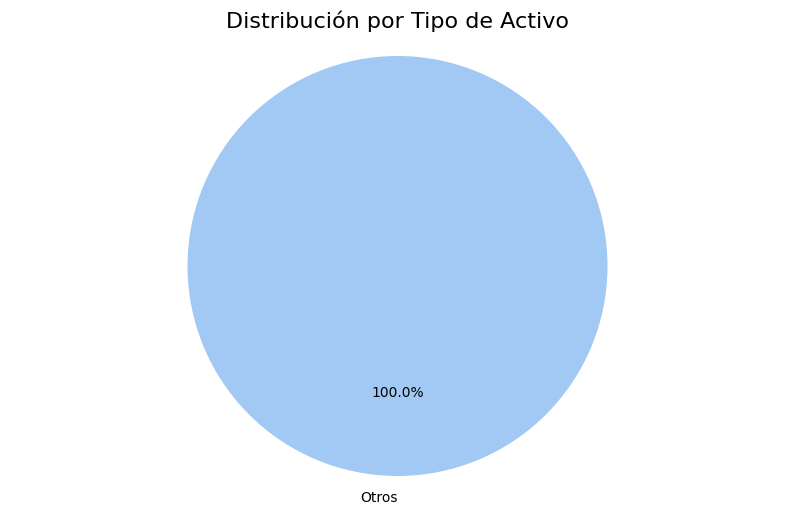

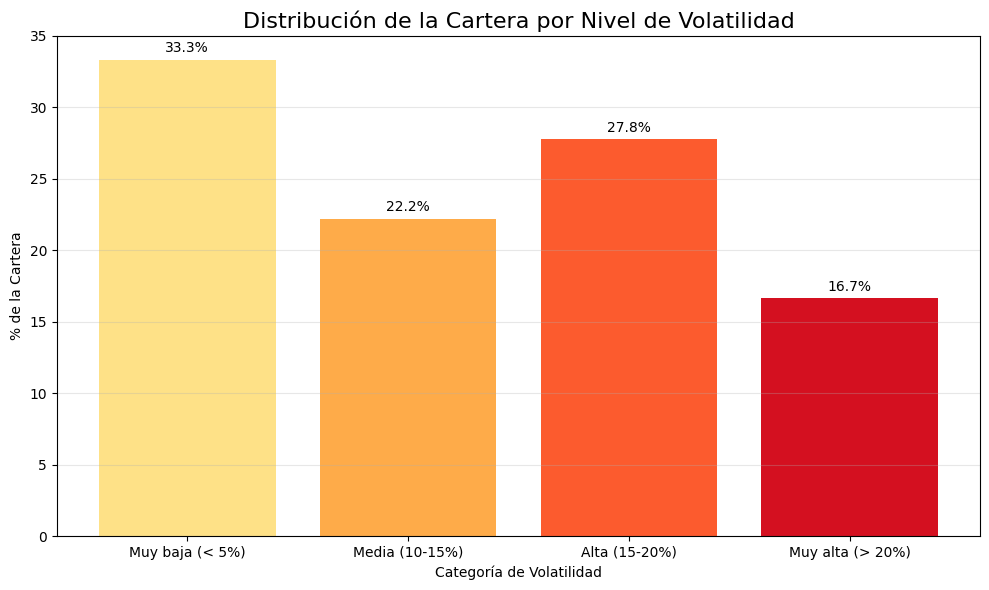

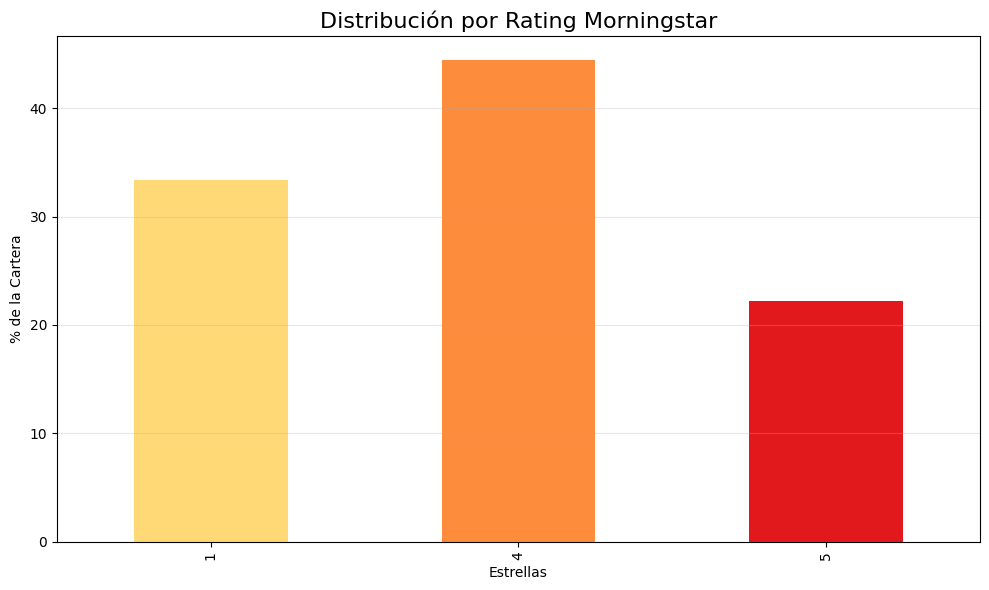

In [8]:
portfolio_composition = portfolio.analyze_portfolio_composition()

## 3. Visualización de Resultados

El método `display_portfolio_analysis` ofrece una vista resumida y formateada de los resultados del análisis.

In [10]:
# Mostrar un resumen del análisis
summary_df = portfolio.display_portfolio_analysis(analysis_results)

print("\nResumen del rendimiento de los fondos en la cartera:")
display(summary_df)


Resumen del rendimiento de los fondos en la cartera:


,ISIN,Nombre,Inversion,valor_actual,Peso,rentabilidad_total,rentabilidad_anualizada,volatilidad_anual,max_drawdown,precio_actual
0,ES0133337008,MyInvestor Roboadvisor Agresivo,3000,3333.354086,0.333333,11.111803,4.555000,4.500000,-16.13,10.076130
1,ES0133411001,CaixaBank RF Flexible,2000,2570.760347,0.222222,28.538017,9.715181,12.060000,-29.71,17.511801
2,IE00B03HD191,Vanguard Global Stock Index,2500,3871.073051,0.277778,54.842922,15.194824,16.450000,-33.76,51.259201
3,IE00BYX5MX67,Fidelity MSCI World,1500,2251.963774,0.166667,50.130918,17.485561,20.160000,-33.62,13.245000
4,TOTAL,TOTAL,9000,12027.151257,1.000000,33.635014,10.812307,12.109444,-26.96,NaN


### Gráfico Interactivo de Comparación

La función `plot_comparison_plotly` genera un gráfico interactivo para comparar la evolución de los fondos de la cartera.

In [15]:
# Generar y mostrar el gráfico interactivo
fig = portfolio.plot_comparison_plotly(portfolio.portfolio_df)
fig.show()

  ✓ Usando datos en caché para IE00BYX5MX67
  ✓ Usando datos en caché para IE00B03HD191
  ✓ Usando datos en caché para ES0133337008
  ✓ Usando datos en caché para ES0133411001


## 4. Comparación de Carteras

La clase `Portfolio` también permite comparar dos carteras diferentes. Crearemos una segunda cartera para demostrar esta funcionalidad.

In [16]:
# Crear una segunda cartera para comparar
portfolio_data_2 = {
    'Nombre': [
        'Vanguard U.S. 500 Stock Index',
        'iShares Emerging Markets',
        'PIMCO Global Bond'
    ],
    'ISIN': [
        'IE00B03SBT81', # Vanguard U.S. 500 Stock Index Fund EUR Acc
        'IE00B0M63177', # iShares Core MSCI Emerging Markets IMI UCITS ETF
        'IE00BDB55G29'  # PIMCO GIS Global Bond E Acc EUR
    ],
    'Inversion': [4000, 2000, 3000],
    'Fecha': ['2022-01-01', '2022-06-01', '2023-01-01']
}
portfolio_df_2 = pd.DataFrame(portfolio_data_2)

print("Cartera 2 para comparación:")
display(portfolio_df_2)

Cartera 2 para comparación:


,Nombre,ISIN,Inversion,Fecha
0,Vanguard U.S. 500 Stock Index,IE00B03SBT81,4000,2022-01-01
1,iShares Emerging Markets,IE00B0M63177,2000,2022-06-01
2,PIMCO Global Bond,IE00BDB55G29,3000,2023-01-01


Cache manager initialized with base path: c:\Users\jaguirrepeman\OneDrive - Deloitte (O365D)\Documents\DS\Finance\data\cache
  ✓ Usando datos en caché para IE00BYX5MX67
  ✓ Usando datos en caché para IE00BYX5MX67
Cache manager initialized with base path: c:\Users\jaguirrepeman\OneDrive - Deloitte (O365D)\Documents\DS\Finance\data\cache
  ✓ Usando datos en caché para IE00B03HD191
  ✓ Usando datos en caché para IE00B03HD191
Cache manager initialized with base path: c:\Users\jaguirrepeman\OneDrive - Deloitte (O365D)\Documents\DS\Finance\data\cache
  ✓ Usando datos en caché para ES0133337008
  ✓ Usando datos en caché para ES0133337008
Cache manager initialized with base path: c:\Users\jaguirrepeman\OneDrive - Deloitte (O365D)\Documents\DS\Finance\data\cache
  ✓ Usando datos en caché para ES0133411001
  ✓ Usando datos en caché para ES0133411001

📊 COMPARACIÓN DE RENTABILIDADES
No hay suficientes datos para comparar las rentabilidades.


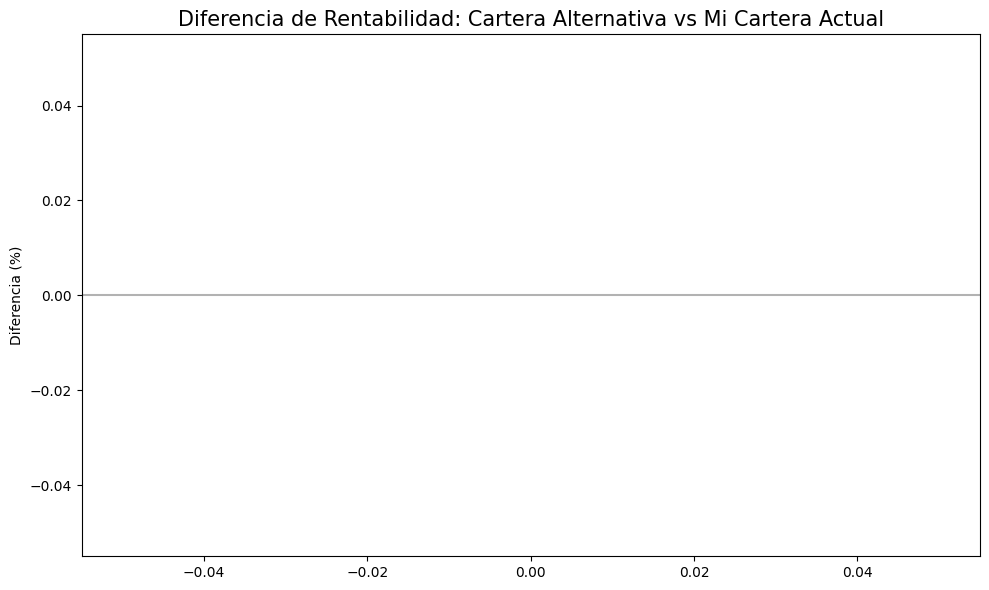

In [18]:
# Comparar las dos carteras
# Usamos una nueva instancia de Portfolio para la comparación
comparison_tool = Portfolio(portfolio_df=portfolio_df.copy()) # Se puede inicializar con una de las carteras

comparison_results = comparison_tool.compare_portfolios(
    portfolio1=portfolio_df,
    portfolio2=portfolio_df_2,
    names=('Mi Cartera Actual', 'Cartera Alternativa')
)

La comparación genera un resumen de las diferencias y un gráfico que visualiza la diferencia de rentabilidad.